In [1]:
from pathlib import Path
import sys

def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "config" / "paths.json").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing config/paths.json")

REPO_ROOT = find_repo_root()
UTILS_DIR = REPO_ROOT / "code" / "utils"
if str(UTILS_DIR) not in sys.path:
    sys.path.append(str(UTILS_DIR))

from project_paths import ensure_project_dirs, load_project_paths

PATHS = ensure_project_dirs(load_project_paths(REPO_ROOT))

import os
import json
import pandas as pd
import numpy as np
import nibabel as nib
from scipy.optimize import curve_fit
from pathlib import Path
from nilearn.surface import SurfaceImage
from nilearn.datasets import load_fsaverage
from nilearn.surface import load_surf_data
import seaborn as sns
import nilearn.surface as surface
from brainspace.plotting import plot_hemispheres
from brainstat.datasets import fetch_template_surface
from brainstat.datasets import fetch_mask, fetch_template_surface
from brainstat.stats.SLM import SLM
from brainstat.stats.terms import FixedEffect
from brainstat.datasets import fetch_parcellation
from brainstat.datasets import fetch_yeo_networks_metadata
from brainstat.context.resting import yeo_networks_associations
import matplotlib.pyplot as plt


In [2]:

bids_root = PATHS["bids_root"]
subjects = ['sub-HDP01', 'sub-HDP02', 'sub-HDP03', 'sub-HDP04', 'sub-HDP06', 'sub-HDP08', 'sub-HDP09', 'sub-HDP10', 'sub-HDP12', 'sub-HDP13', 'sub-HDP15', 'sub-HDP17', 'sub-HDP18', 'sub-HDP19']
sessions = ["ses-01", "ses-02"]
figure_output_path = PATHS["surface_figures_root"] / 'CMRglc'
figure_output_path.mkdir(parents=True, exist_ok=True)

participants_file = PATHS["participants_file"]
participants_data = pd.read_csv(participants_file, sep="\t")

fsaverage = load_fsaverage(mesh='fsaverage')
fsa_mesh = fsaverage['pial']

LC = 0.65


[load_fsaverage] Dataset found in /Users/Edge/nilearn_data/fsaverage


### Surface-based Patlak Modeling

In [3]:
# Define Patlak Model
def patlak_model(x, k_i, v_0):
    """Patlak model: y = K_i * integral(Cp)/Cp + v0"""
    return k_i * x + v_0 

# Loop through subjects and sessions
for subject in subjects:
    for session in sessions:
        print(f"Processing {subject} {session}...")

        # Retrieve blood glucose value
        glucose_column = f"blood_glucose_{session}"
        blood_glucose = participants_data.loc[participants_data['participant_id'] == subject, glucose_column].values
        if len(blood_glucose) == 0:
            print(f"Missing glucose value for {subject} {session}, skipping CMRglc calculation.")
            continue
        blood_glucose = blood_glucose[0]
        
        # Define input file paths
        pet_file = bids_root / "derivatives/petprep_extract_tacs_smoothed" / subject / session / f"{subject}_{session}_space-mni305_pet.nii.gz"
        pet_json_file = bids_root / subject / session / "pet" / f"{subject}_{session}_pet.json"
        idif_file = bids_root / "derivatives/idif_aorta" / subject / session / "pet" / f"{subject}_{session}_inputfunction_feng_original_format.tsv"
        idif_json_file = bids_root / "derivatives/idif_aorta" / subject / session / "pet" / f"{subject}_{session}_inputfunction_feng_original_format.json"

        # Surface files
        surface_files = {
            "left": bids_root / "derivatives/petprep_extract_tacs_smoothed" / subject / session / f"{subject}_{session}_space-fsaverage_hemi-L_desc-sm6_pet.nii.gz",
            "right": bids_root / "derivatives/petprep_extract_tacs_smoothed" / subject / session / f"{subject}_{session}_space-fsaverage_hemi-R_desc-sm6_pet.nii.gz"
        }

        # Output directory
        output_dir = bids_root / "derivatives/voxelwise_modeling_maps" / subject / session / "pet"
        output_dir.mkdir(parents=True, exist_ok=True)

        # Load PET dynamic data
        pet_img = nib.load(pet_file)
        pet_data = pet_img.get_fdata()

        # Load PET metadata
        with open(pet_json_file, "r") as f:
            pet_metadata = json.load(f)
        frame_start_times = np.array(pet_metadata["FrameTimesStart"])
        frame_durations = np.array(pet_metadata["FrameDuration"])
        mid_times = frame_start_times + (frame_durations / 2)

        # Load IDIF data
        idif_data = pd.read_csv(idif_file, sep="\t")
        with open(idif_json_file, "r") as f:
            idif_metadata = json.load(f)
        idif_values = idif_data["IDIF"].to_numpy()
        assert len(idif_values) == len(mid_times), "IDIF and PET frames do not match!"

        # Convert frame durations to minutes
        frame_durations_min = frame_durations / 60

        # Integrate IDIF over time in minutes
        idif_integral = np.cumsum(idif_values * frame_durations_min)


        # Create dictionaries to store the surface data for left and right hemispheres
        ki_data = {"left": [], "right": []}
        v_0_data = {"left": [], "right": []}
        cmrglc_data = {"left": [], "right": []}

        # Surface-level Patlak fitting using nilearn
        for hemi, surf_file in surface_files.items():
            if surf_file.exists():
                # Load surface PET data
                surf_data = surface.load_surf_data(surf_file)  # Shape: (163842, 23)

                # Prepare output arrays for this hemisphere
                ki_surf = np.zeros(surf_data.shape[0])  # 163842 vertices
                v_0_surf = np.zeros(surf_data.shape[0])
                cmrglc_surf = np.zeros(surf_data.shape[0])

                for v in range(surf_data.shape[0]):  # Loop over vertices
                    tac = surf_data[v, :]

                    # Ensure enough time points
                    min_time_points = 3
                    y_values = tac[-10:] / idif_values[-10:]
                    x_values = idif_integral[-10:] / idif_values[-10:]

                    if len(x_values) < min_time_points or len(y_values) < min_time_points:
                        continue  # Skip if too few data points

                    try:
                        popt, _ = curve_fit(patlak_model, x_values, y_values, p0=[0.04, 0.03])
                        ki_surf[v] = popt[0]
                        v_0_surf[v] = popt[1]
                        cmrglc_surf[v] = popt[0] * blood_glucose * 100  / LC# Convert to CMRglc units: µmol/100g/min
                    except RuntimeError:
                        pass  # Skip vertices that fail to fit

                # Assign results to the corresponding hemisphere data
                ki_data[hemi] = ki_surf
                v_0_data[hemi] = v_0_surf
                cmrglc_data[hemi] = cmrglc_surf

        # Now create the SurfaceImage objects using the combined data and fsaverage mesh
        ki_surf_img = SurfaceImage(mesh=fsa_mesh, data=ki_data)
        v0_surf_img = SurfaceImage(mesh=fsa_mesh, data=v_0_data)
        cmrglc_img = SurfaceImage(mesh=fsa_mesh, data=cmrglc_data)

        # Save the surface data to GIFTI format
        ki_surf_img.data.to_filename(output_dir / f"{subject}_{session}_space-fsaverage_desc-sm6_patlak_ki.gii")
        v0_surf_img.data.to_filename(output_dir / f"{subject}_{session}_space-fsaverage_desc-sm6_patlak_v0.gii")
        cmrglc_img.data.to_filename(output_dir / f"{subject}_{session}_space-fsaverage_desc-sm6_patlak_cmrglc.gii")

        print(f"{subject} {session} surface-level fitting completed.")


print("Batch Patlak analysis complete.")


Processing sub-HDP01 ses-01...
sub-HDP01 ses-01 surface-level fitting completed.
Processing sub-HDP01 ses-02...
sub-HDP01 ses-02 surface-level fitting completed.
Processing sub-HDP02 ses-01...
sub-HDP02 ses-01 surface-level fitting completed.
Processing sub-HDP02 ses-02...
sub-HDP02 ses-02 surface-level fitting completed.
Processing sub-HDP03 ses-01...
sub-HDP03 ses-01 surface-level fitting completed.
Processing sub-HDP03 ses-02...
sub-HDP03 ses-02 surface-level fitting completed.
Processing sub-HDP04 ses-01...
sub-HDP04 ses-01 surface-level fitting completed.
Processing sub-HDP04 ses-02...
sub-HDP04 ses-02 surface-level fitting completed.
Processing sub-HDP06 ses-01...
sub-HDP06 ses-01 surface-level fitting completed.
Processing sub-HDP06 ses-02...
sub-HDP06 ses-02 surface-level fitting completed.
Processing sub-HDP08 ses-01...
sub-HDP08 ses-01 surface-level fitting completed.
Processing sub-HDP08 ses-02...
sub-HDP08 ses-02 surface-level fitting completed.
Processing sub-HDP09 ses-01.

#### Group averages

In [4]:
# Define paths
patlak_dir = bids_root / "derivatives/voxelwise_modeling_maps"
group_avg_dir = patlak_dir / "group_averages"

# Dictionaries to store individual maps
placebo_ki_maps = {}
drug_ki_maps = {}
placebo_cmrglc_maps = {}
drug_cmrglc_maps = {}

# Iterate through subjects and sessions
for _, row in participants_data.iterrows():
    subject = row["participant_id"]
    
    for session, condition in [("ses-01", row["drug_ses-01"]), ("ses-02", row["drug_ses-02"])]:
        # Define file paths for left and right hemisphere
        ki_files = {
            "left": patlak_dir / subject / session / "pet" / f"{subject}_{session}_space-fsaverage_desc-sm6_patlak_ki_hemi-L.gii",
            "right": patlak_dir / subject / session / "pet" / f"{subject}_{session}_space-fsaverage_desc-sm6_patlak_ki_hemi-R.gii"
        }
        cmrglc_files = {
            "left": patlak_dir / subject / session / "pet" / f"{subject}_{session}_space-fsaverage_desc-sm6_patlak_cmrglc_hemi-L.gii",
            "right": patlak_dir / subject / session / "pet" / f"{subject}_{session}_space-fsaverage_desc-sm6_patlak_cmrglc_hemi-R.gii"
        }
        
        # Load and store K_i maps
        if ki_files["left"].exists() and ki_files["right"].exists():
            ki_left = load_surf_data(ki_files["left"])
            ki_right = load_surf_data(ki_files["right"])
            ki_combined = {"left": ki_left, "right": ki_right}
            if condition == "Placebo":
                placebo_ki_maps[subject] = ki_combined
            elif condition == "Verum":
                drug_ki_maps[subject] = ki_combined

        # Load and store CMRglc maps
        if cmrglc_files["left"].exists() and cmrglc_files["right"].exists():
            cmrglc_left = load_surf_data(cmrglc_files["left"])
            cmrglc_right = load_surf_data(cmrglc_files["right"])
            cmrglc_combined = {"left": cmrglc_left, "right": cmrglc_right}
            if condition == "Placebo":
                placebo_cmrglc_maps[subject] = cmrglc_combined
            elif condition == "Verum":
                drug_cmrglc_maps[subject] = cmrglc_combined

# Compute and save group averages
def compute_surface_average(surface_maps):
    """Compute the average for left and right hemispheres separately."""
    left_avg = np.mean([m["left"] for m in surface_maps.values()], axis=0)
    right_avg = np.mean([m["right"] for m in surface_maps.values()], axis=0)
    return {"left": left_avg, "right": right_avg}

# Compute and save placebo K_i map
if placebo_ki_maps:
    placebo_ki_avg = compute_surface_average(placebo_ki_maps)
    placebo_ki_img = SurfaceImage(mesh=fsa_mesh, data=placebo_ki_avg)
    placebo_ki_img.data.to_filename(group_avg_dir / "placebo_avg_space-fsaverage_desc-sm6_patlak_ki.gii")

# Compute and save drug K_i map
if drug_ki_maps:
    drug_ki_avg = compute_surface_average(drug_ki_maps)
    drug_ki_img = SurfaceImage(mesh=fsa_mesh, data=drug_ki_avg)
    drug_ki_img.data.to_filename(group_avg_dir / "drug_avg_space-fsaverage_desc-sm6_patlak_ki.gii")

# Compute and save placebo CMRglc map
if placebo_cmrglc_maps:
    placebo_cmrglc_avg = compute_surface_average(placebo_cmrglc_maps)
    placebo_cmrglc_img = SurfaceImage(mesh=fsa_mesh, data=placebo_cmrglc_avg)
    placebo_cmrglc_img.data.to_filename(group_avg_dir / "placebo_avg_space-fsaverage_desc-sm6_patlak_cmrglc.gii")

# Compute and save drug CMRglc map
if drug_cmrglc_maps:
    drug_cmrglc_avg = compute_surface_average(drug_cmrglc_maps)
    drug_cmrglc_img = SurfaceImage(mesh=fsa_mesh, data=drug_cmrglc_avg)
    drug_cmrglc_img.data.to_filename(group_avg_dir / "drug_avg_space-fsaverage_desc-sm6_patlak_cmrglc.gii")

# Compute and save drug-placebo delta CMRglc map
if placebo_cmrglc_maps and drug_cmrglc_maps:
    delta_cmrglc_avg = {
        "left": drug_cmrglc_avg["left"] - placebo_cmrglc_avg["left"],
        "right": drug_cmrglc_avg["right"] - placebo_cmrglc_avg["right"],
    }
    delta_cmrglc_img = SurfaceImage(mesh=fsa_mesh, data=delta_cmrglc_avg)
    delta_cmrglc_img.data.to_filename(group_avg_dir / "drug_minus_placebo_avg_space-fsaverage_desc-sm6_patlak_cmrglc.gii")

print("Group average surface maps saved.")


Group average surface maps saved.


In [5]:
# Combine drug average surface data
drug_cmrglc_avg_flat = np.hstack([drug_cmrglc_avg["left"], drug_cmrglc_avg["right"]])
# Replace values = 0 with np.nan (to color them properly)
drug_cmrglc_avg_flat[drug_cmrglc_avg_flat == 0] = np.nan

# min and max values for plotting
min_val_drug = np.nanmin(drug_cmrglc_avg_flat)
max_val_drug = np.nanmax(drug_cmrglc_avg_flat)
print(f"Drug: Min: {min_val_drug}, Max: {max_val_drug}")


# Combine placebo average surface data
placebo_cmrglc_avg_flat = np.hstack([placebo_cmrglc_avg["left"], placebo_cmrglc_avg["right"]])
placebo_cmrglc_avg_flat[placebo_cmrglc_avg_flat == 0] = np.nan

# min and max values for plotting
min_val_placebo = np.nanmin(placebo_cmrglc_avg_flat)
max_val_placebo = np.nanmax(placebo_cmrglc_avg_flat)
print(f"Placebo: Min {min_val_placebo}, Max: {max_val_placebo}")


# Combine drug average surface data
delta_cmrglc_avg_flat = np.hstack([delta_cmrglc_avg["left"], delta_cmrglc_avg["right"]])
# Replace values = 0 with np.nan (to color them properly)
delta_cmrglc_avg_flat[delta_cmrglc_avg_flat == 0] = np.nan

# min and max values for plotting
min_val_delta = np.nanmin(delta_cmrglc_avg_flat)
max_val_delta = np.nanmax(delta_cmrglc_avg_flat)
print(f"Delta: Min: {min_val_delta}, Max: {max_val_delta}")

Drug: Min: 12.856524467468262, Max: 39.65717697143555
Placebo: Min 11.935623168945312, Max: 34.59123992919922
Delta: Min: -2.4397659301757812, Max: 6.697229385375977


In [6]:
# Load fsaverage surface data
pial_left, pial_right = fetch_template_surface("fsaverage", join=False)

In [7]:
# Plot the drug average CMRglc surface map
plot_hemispheres(pial_left, pial_right, drug_cmrglc_avg_flat, color_bar=True, color_range=(11.9, 39.7),
        label_text=["DMT + harmine"], cmap="CMRmap", embed_nb=True, size=(1400, 200), zoom=1.45,
        nan_color=(0.7, 0.7, 0.7, 1), cb__labelTextProperty={"fontSize": 12}, interactive=False, screenshot=True, filename=f'{figure_output_path}/drug_cmrglc_avg_desc-sm6.png')

# Plot the placebo average CMRglc surface map
plot_hemispheres(pial_left, pial_right, placebo_cmrglc_avg_flat, color_bar=True, color_range=(11.9, 39.7),
        label_text=["Placebo"], cmap="CMRmap", embed_nb=True, size=(1400, 200), zoom=1.45,
        nan_color=(0.7, 0.7, 0.7, 1), cb__labelTextProperty={"fontSize": 12}, interactive=False, screenshot=True, filename=f'{figure_output_path}/placebo_cmrglc_avg_desc-sm6.png')

# Plot the delta average CMRglc surface map
plot_hemispheres(pial_left, pial_right, delta_cmrglc_avg_flat, color_bar=True, color_range=(-2.5, 6.7),
        label_text=["∆CMRglc"], cmap="coolwarm", embed_nb=True, size=(1400, 200), zoom=1.45,
        nan_color=(0.7, 0.7, 0.7, 1), cb__labelTextProperty={"fontSize": 12}, interactive=False, screenshot=True, filename=f'{figure_output_path}/delta_cmrglc_avg_desc-sm6.png')


'/Users/Edge/Documents/03_Research/01_PhD_Projekt/09_Analysis/04_HDP/HDP_fdg_pet_public_repo/outputs/figures/surface_analysis/CMRglc/delta_cmrglc_avg_desc-sm6.png'

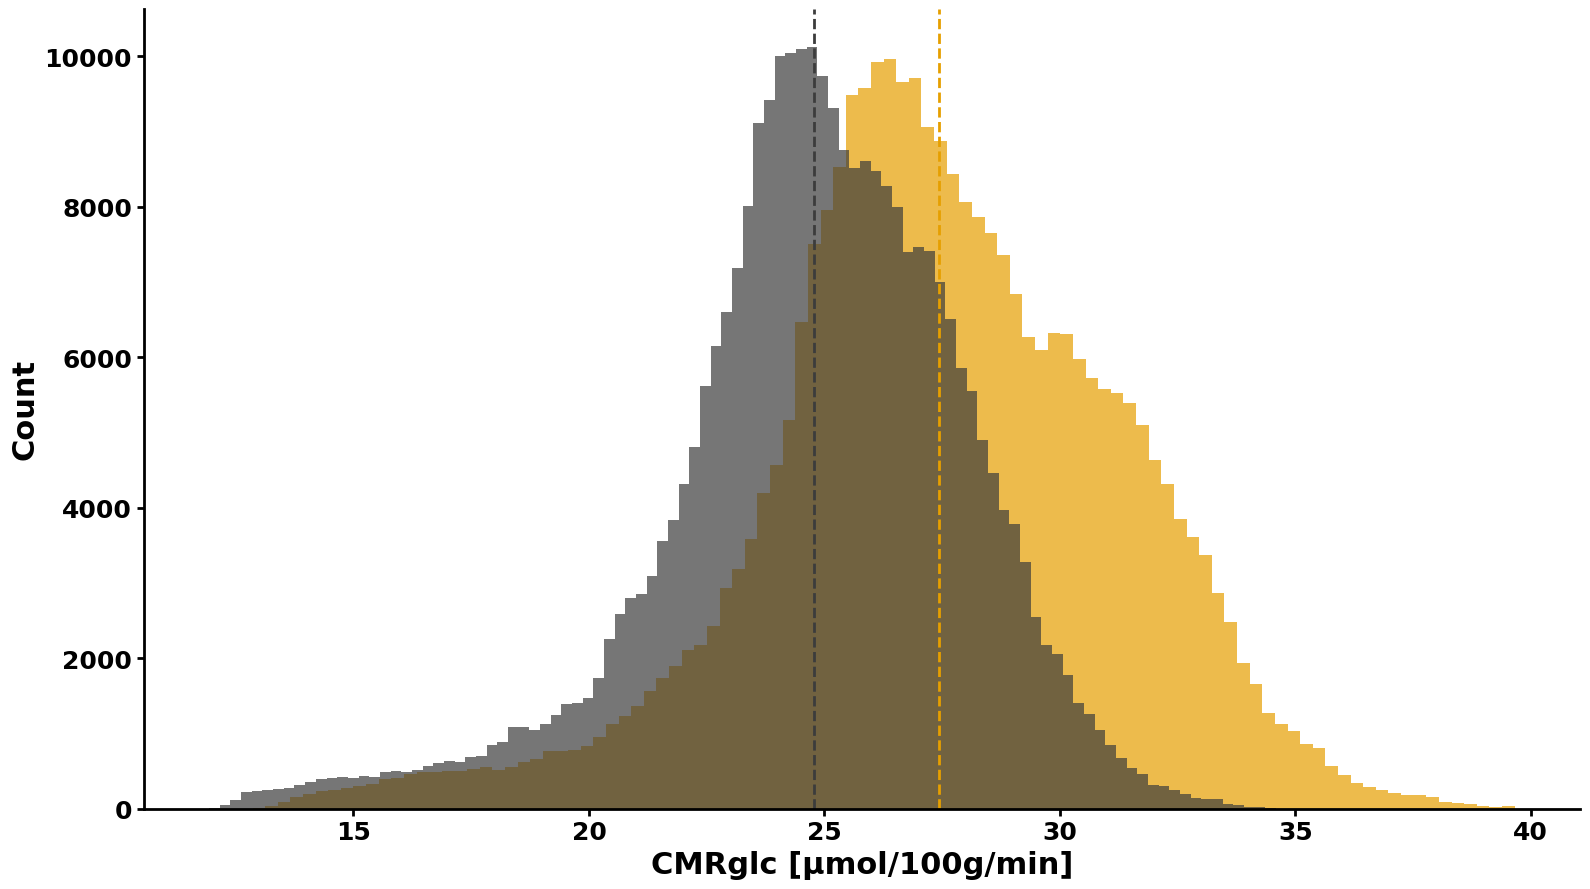

In [8]:
colors = {'Placebo': '#3C3C3C', 'DMT + har': '#E69F00'}

# Calculate means
mean_drug = np.nanmean(drug_cmrglc_avg_flat)
mean_placebo = np.nanmean(placebo_cmrglc_avg_flat)

# Create figure and axis
fig, axs = plt.subplots(1, 1, figsize=(16, 9))

# Plot histograms
axs.hist(drug_cmrglc_avg_flat, bins=100, color=colors['DMT + har'], alpha=0.7, label='DMT + har', edgecolor='none')
axs.hist(placebo_cmrglc_avg_flat, bins=100, color=colors['Placebo'], alpha=0.7, label='Placebo', edgecolor='none')

# Add vertical lines for means
axs.axvline(mean_drug, color=colors['DMT + har'], linestyle='--', linewidth=2)
axs.axvline(mean_placebo, color=colors['Placebo'], linestyle='--', linewidth=2)

# Customize appearance
axs.spines['top'].set_visible(False)    
axs.spines['right'].set_visible(False)  
axs.set_xlabel('CMRglc [µmol/100g/min]', fontsize=22, fontweight='bold')  
axs.set_ylabel('Count', fontsize=22, fontweight='bold')           
axs.tick_params(axis='both', which='major', labelsize=18, width=2, length=5)  
axs.grid(False)
axs.spines['left'].set_linewidth(2)
axs.spines['bottom'].set_linewidth(2)

# Bold tick labels
for label in axs.get_xticklabels():
    label.set_fontweight('bold')
for label in axs.get_yticklabels():
    label.set_fontweight('bold')

# Add legend
#axs.legend(fontsize=13, frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(figure_output_path, 'Fsaverage_desc-sm6_Hist_plot_with_means.png'), dpi=600, bbox_inches='tight')
# plt.close()

plt.show()

#### write function to annotate stats in plot

In [9]:
def draw_flat_annotations(ax, annotations, top_margin=0.01, text_distance=0.002, fontsize=20):
    """
    Draws non-stacked statistical annotations with brackets for distinct x-locations (e.g., across networks).
    
    Parameters:
        ax: Matplotlib axis object.
        annotations: List of tuples (x1, x2, pval)
        top_margin: Vertical offset above the plot's y-max.
        text_distance: Additional height for stars or p-value text.
        fontsize: Font size of the stars (n.s. will be smaller).
    """
    y_lim = ax.get_ylim()
    y_max = y_lim[1]

    for (x1, x2, pval) in annotations:
        # Consistent height for all annotations
        y = y_max + top_margin

        # Define bracket width
        bar_height = text_distance
        tick_height = text_distance * 0.6  # shorter vertical ticks on bracket

        # Draw bracket like: ┐      ┌
        #                  └──────┘
        ax.plot([x1, x1, x2, x2],
                [y, y + tick_height, y + tick_height, y],
                color='black', lw=1.5)

        # Generate p-value text and adjust size
        if pval < 0.001:
            text = '***'
            text_fs = fontsize
        elif pval < 0.01:
            text = '**'
            text_fs = fontsize
        elif pval < 0.05:
            text = '*'
            text_fs = fontsize
        else:
            text = 'n.s.'
            text_fs = fontsize * 0.75  # Smaller size for "n.s."

        # Center the text above the bracket
        ax.text((x1 + x2) / 2, y + tick_height,
                text, ha='center', va='bottom', fontsize=text_fs, weight='bold')

    # Optionally, expand y-limits to make room
    ax.set_ylim(y_lim[0], y_max + top_margin + tick_height + text_distance + 0.01)

### Shannon entropy of vertex-wise CMRglc distributions

In [10]:
from scipy.stats import entropy, ttest_rel

# Descriptive spatial entropy of the vertex-wise CMRglc distribution.
# This quantifies how broad the cortical value histogram is and should not be
# interpreted as a direct measure of functional or temporal brain entropy.
def flatten_surface_map(surface_map):
    return np.concatenate([
        np.asarray(surface_map['left']).ravel(),
        np.asarray(surface_map['right']).ravel(),
    ])

def prepare_entropy_values(values):
    values = np.asarray(values, dtype=float)
    return values[np.isfinite(values) & (values != 0)]

def compute_histogram_shannon_entropy(values, bin_edges):
    counts, _ = np.histogram(values, bins=bin_edges)
    probabilities = counts.astype(float) / counts.sum()
    probabilities = probabilities[probabilities > 0]
    return entropy(probabilities, base=2)

entropy_subjects = sorted(set(drug_cmrglc_maps).intersection(placebo_cmrglc_maps))

all_entropy_values = []
for subject in entropy_subjects:
    all_entropy_values.extend(
        prepare_entropy_values(flatten_surface_map(placebo_cmrglc_maps[subject]))
    )
    all_entropy_values.extend(
        prepare_entropy_values(flatten_surface_map(drug_cmrglc_maps[subject]))
    )

all_entropy_values = np.asarray(all_entropy_values)
entropy_bin_edges = np.histogram_bin_edges(all_entropy_values, bins=100)

vertex_entropy_rows = []
for subject in entropy_subjects:
    placebo_values = prepare_entropy_values(flatten_surface_map(placebo_cmrglc_maps[subject]))
    drug_values = prepare_entropy_values(flatten_surface_map(drug_cmrglc_maps[subject]))

    placebo_entropy_bits = compute_histogram_shannon_entropy(placebo_values, entropy_bin_edges)
    drug_entropy_bits = compute_histogram_shannon_entropy(drug_values, entropy_bin_edges)

    vertex_entropy_rows.append({
        'participant_id': subject,
        'Placebo_entropy_bits': placebo_entropy_bits,
        'DMT_har_entropy_bits': drug_entropy_bits,
        'delta_entropy_bits': drug_entropy_bits - placebo_entropy_bits,
    })

vertex_entropy_df = pd.DataFrame(vertex_entropy_rows).sort_values('participant_id').reset_index(drop=True)

vertex_entropy_summary_df = pd.DataFrame({
    'mean_entropy_bits': [
        vertex_entropy_df['Placebo_entropy_bits'].mean(),
        vertex_entropy_df['DMT_har_entropy_bits'].mean(),
    ],
    'sd_entropy_bits': [
        vertex_entropy_df['Placebo_entropy_bits'].std(ddof=1),
        vertex_entropy_df['DMT_har_entropy_bits'].std(ddof=1),
    ],
}, index=['Placebo', 'DMT + har'])

vertex_entropy_ttest = ttest_rel(
    vertex_entropy_df['DMT_har_entropy_bits'],
    vertex_entropy_df['Placebo_entropy_bits'],
)

vertex_entropy_stats = pd.Series({
    'n_subjects': len(vertex_entropy_df),
    'mean_delta_entropy_bits': vertex_entropy_df['delta_entropy_bits'].mean(),
    'sd_delta_entropy_bits': vertex_entropy_df['delta_entropy_bits'].std(ddof=1),
    't_statistic': vertex_entropy_ttest.statistic,
    'p_value': vertex_entropy_ttest.pvalue,
})

# Direct entropy values for the group-average histograms shown descriptively in Fig. 3C.
group_average_vertex_entropy_bits = pd.Series({
    'Placebo': compute_histogram_shannon_entropy(
        prepare_entropy_values(placebo_cmrglc_avg_flat),
        entropy_bin_edges,
    ),
    'DMT + har': compute_histogram_shannon_entropy(
        prepare_entropy_values(drug_cmrglc_avg_flat),
        entropy_bin_edges,
    ),
})

display(vertex_entropy_summary_df.round(4))
display(vertex_entropy_stats.round(6).rename('value').to_frame())
display(group_average_vertex_entropy_bits.round(4).rename('group_average_entropy_bits').to_frame())


,mean_entropy_bits,sd_entropy_bits
Placebo,4.8784,0.2691
DMT + har,5.1759,0.4142


,value
n_subjects,14.000000
mean_delta_entropy_bits,0.297490
sd_delta_entropy_bits,0.478562
t_statistic,2.325939
p_value,0.036840


,group_average_entropy_bits
Placebo,4.5623
DMT + har,4.8414


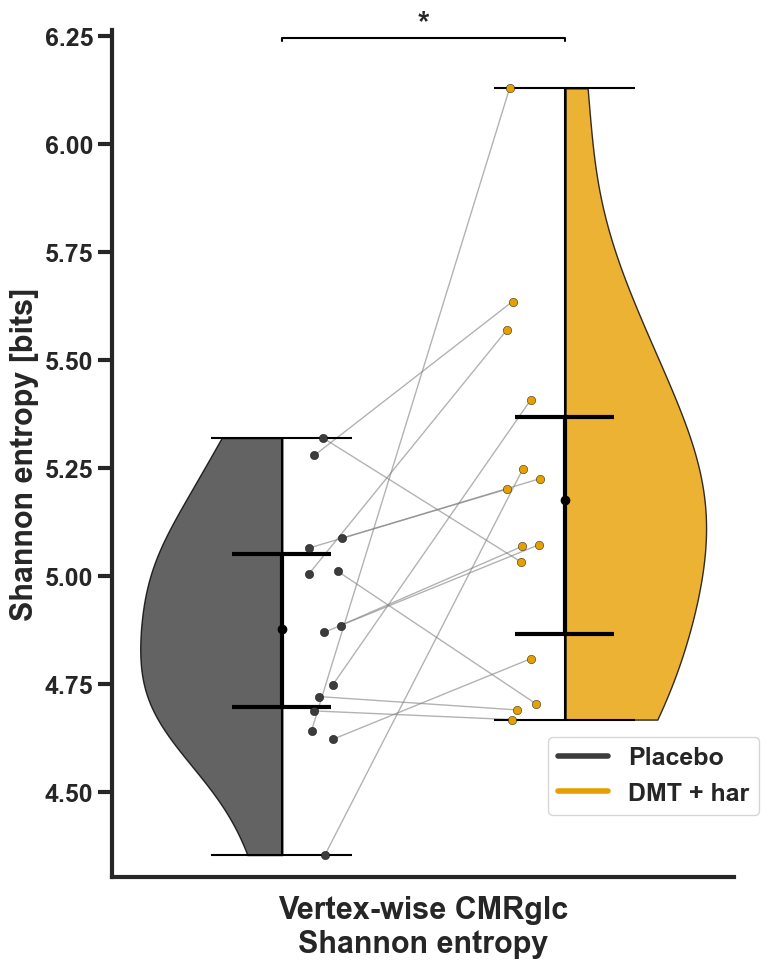

           mean_entropy_bits  sd_entropy_bits
Placebo               4.8784           0.2691
DMT + har             5.1759           0.4142
n_subjects                 14.000000
mean_delta_entropy_bits     0.297490
sd_delta_entropy_bits       0.478562
t_statistic                 2.325939
p_value                     0.036840
dtype: float64
Placebo      4.5623
DMT + har    4.8414
dtype: float64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib

sns.set_theme(style="ticks", rc={"figure.figsize": (8, 10)}, font_scale=1.4)
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})

colors = {'Placebo': '#3C3C3C', 'DMT + har': '#E69F00'}
conditions = ['Placebo', 'DMT + har']
offset = 0.2
jitter_strength = 0.015

fig, ax = plt.subplots(figsize=(8, 10))

plot_specs = [
    {
        'label': 'Placebo',
        'values': vertex_entropy_df['Placebo_entropy_bits'].values,
        'position': 0 - offset,
        'color': colors['Placebo'],
        'side': 'left',
    },
    {
        'label': 'DMT + har',
        'values': vertex_entropy_df['DMT_har_entropy_bits'].values,
        'position': 0 + offset,
        'color': colors['DMT + har'],
        'side': 'right',
    },
]

# Half violins
for spec in plot_specs:
    parts = ax.violinplot(
        dataset=spec['values'],
        positions=[spec['position']],
        showextrema=True,
        widths=0.4,
    )

    for pc in parts['bodies']:
        pc.set_facecolor(spec['color'])
        pc.set_edgecolor('black')
        pc.set_alpha(0.8)

        path = pc.get_paths()[0]
        vertices = path.vertices
        mean_x = np.mean(vertices[:, 0])

        if spec['side'] == 'left':
            vertices[:, 0] = np.clip(vertices[:, 0], -np.inf, mean_x)
        else:
            vertices[:, 0] = np.clip(vertices[:, 0], mean_x, np.inf)

    q1, q3 = np.percentile(spec['values'], [25, 75])
    ax.plot(spec['position'], np.mean(spec['values']), 'o', color='black', markersize=6)
    ax.vlines(spec['position'], q1, q3, color='black', linestyle='-', lw=3)
    ax.hlines(q1, spec['position'] - 0.07, spec['position'] + 0.07, color='black', linestyle='-', lw=3)
    ax.hlines(q3, spec['position'] - 0.07, spec['position'] + 0.07, color='black', linestyle='-', lw=3)

    parts['cbars'].set_color('black')
    parts['cmins'].set_color('black')
    parts['cmaxes'].set_color('black')

# Paired subject points
for _, row in vertex_entropy_df.iterrows():
    jitter = np.random.normal(0, jitter_strength)
    x_placebo = -offset * 0.7 + jitter
    x_drug = offset * 0.7 + jitter

    y_placebo = row['Placebo_entropy_bits']
    y_drug = row['DMT_har_entropy_bits']

    ax.plot([x_placebo, x_drug], [y_placebo, y_drug], color='gray', alpha=0.6, lw=1, zorder=1)
    ax.scatter(x_placebo, y_placebo, color=colors['Placebo'], zorder=2, alpha=1, edgecolor='black', linewidth=0.3)
    ax.scatter(x_drug, y_drug, color=colors['DMT + har'], zorder=2, alpha=1, edgecolor='black', linewidth=0.3)

# Formatting
sns.despine()
ax.set_xticks([0])
ax.set_xticklabels(['Vertex-wise CMRglc\nShannon entropy'], fontsize=22, weight='bold')
ax.set_ylabel('Shannon entropy [bits]', fontsize=22, weight='bold')
ax.set_xlabel(None)

all_values = np.concatenate([
    vertex_entropy_df['Placebo_entropy_bits'].values,
    vertex_entropy_df['DMT_har_entropy_bits'].values,
])
ax.set_ylim(all_values.min() - 0.05, all_values.max() + 0.08)

ax.tick_params(axis='y', which='major', labelsize=18)
ax.spines['left'].set_linewidth(3)
ax.spines['bottom'].set_linewidth(3)
ax.tick_params(axis='y', which='both', width=3, length=10)
ax.tick_params(axis='x', which='both', width=2, color='white', length=10)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

handles = [matplotlib.lines.Line2D([0], [0], color=color, lw=4) for color in colors.values()]
labels = list(colors.keys())
ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.68, 0.18), fontsize=18)

# p-value annotation with your existing helper
annotations = [(-offset, offset, vertex_entropy_stats['p_value'])]
draw_flat_annotations(ax, annotations, top_margin=0.03, text_distance=0.01, fontsize=22)

plt.tight_layout()
plt.savefig(
    os.path.join(figure_output_path, 'vertexwise_shannon_entropy_desc-sm6.png'),
    dpi=600,
    bbox_inches='tight'
)
plt.show()

# Optional: print descriptive values below the figure
print(vertex_entropy_summary_df.round(4))
print(vertex_entropy_stats.round(6))
print(group_average_vertex_entropy_bits.round(4))


In [12]:
cmrglc_maps = {
    "drug": {subject: np.concatenate([data["left"], data["right"]]) for subject, data in drug_cmrglc_maps.items()},
    "placebo": {subject: np.concatenate([data["left"], data["right"]]) for subject, data in placebo_cmrglc_maps.items()}
}

# Flatten the data stored in the dictionary
all_arrays = np.vstack([data for group in cmrglc_maps.values() for data in group.values()])

condition = ['drug'] * 14 + ['placebo'] * 14
df_model = pd.DataFrame({'participant_id':participants_data.participant_id.tolist() * 2, 
                             'condition': condition})

In [13]:
term_subject = FixedEffect(df_model.participant_id)
term_drug = FixedEffect(df_model.condition)

model_drug =  term_drug + term_subject

contrast_drug = (df_model.condition =='drug').astype(int) - (df_model.condition =='placebo').astype(int)
mask = fetch_mask("fsaverage")
# Model drug - placebo patlak cmrglc maps
slm_model = SLM(
    model_drug,
    contrast_drug,
    surf='fsaverage',
    mask=mask,
    correction=["fdr", "rft"],
    two_tailed=True,
    cluster_threshold=0.05,
)
slm_model.fit(all_arrays)

#t_values_to_fsa5 = map_to_labels(slm_pre_verum_placebo_model.t, schaefer_400_fs5, mask=mask, fill=np.nan)
#p_values_to_fsa5 = map_to_labels(slm_pre_verum_placebo_model.Q, schaefer_400_fs5, mask=mask, fill=np.nan)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/brainstat/stats/_linear_model.py:445: RuntimeWarning: invalid value encountered in divide
  u = Y[i, :, j] / normr


In [14]:
plot_hemispheres(pial_left, pial_right, slm_model.t, color_bar=True, color_range=(0, 4),
        label_text=["t-values"], cmap="viridis", embed_nb=True, size=(1400, 200), zoom=1.45,
        nan_color=(0.7, 0.7, 0.7, 1), cb__labelTextProperty={"fontSize": 12}, interactive=False, screenshot=True, filename=f'{figure_output_path}/cmrglc_t_stat_map-sm6.png')

'/Users/Edge/Documents/03_Research/01_PhD_Projekt/09_Analysis/04_HDP/HDP_fdg_pet_public_repo/outputs/figures/surface_analysis/CMRglc/cmrglc_t_stat_map-sm6.png'

In [15]:
# 1. Copy the t-values
t_vals = np.copy(slm_model.t).squeeze()

# 2. Copy the p-values
p_vals = np.copy(slm_model.P["pval"]["C"])

# 3. Mask the t-values where p > 0.05 or mask is False
np.place(t_vals, np.logical_or(p_vals > 0.05, ~mask), np.nan)

# 4. Plot masked t-values
plot_hemispheres(
    pial_left, pial_right, t_vals.T, 
    color_bar=True, color_range=(0, 4),
    label_text=["p < 0.05"], cmap="autumn", 
    embed_nb=True, size=(1400, 200), zoom=1.45,
    nan_color=(0.7, 0.7, 0.7, 1), cb__labelTextProperty={"fontSize": 12},
    interactive=False,
    screenshot=True, filename=f'{figure_output_path}/cmrglc_t_stat_map_p05-sm6.png'
)

'/Users/Edge/Documents/03_Research/01_PhD_Projekt/09_Analysis/04_HDP/HDP_fdg_pet_public_repo/outputs/figures/surface_analysis/CMRglc/cmrglc_t_stat_map_p05-sm6.png'

## model with cluster_threshold = 0.01

In [16]:
term_subject = FixedEffect(df_model.participant_id)
term_drug = FixedEffect(df_model.condition)

model_drug =  term_drug + term_subject

contrast_drug = (df_model.condition =='drug').astype(int) - (df_model.condition =='placebo').astype(int)
mask = fetch_mask("fsaverage")
# Model drug - placebo patlak cmrglc maps
slm_model_2 = SLM(
    model_drug,
    contrast_drug,
    surf='fsaverage',
    mask=mask,
    correction=["fdr", "rft"],
    two_tailed=True,
    cluster_threshold=0.01,
)
slm_model_2.fit(all_arrays)

#t_values_to_fsa5 = map_to_labels(slm_pre_verum_placebo_model.t, schaefer_400_fs5, mask=mask, fill=np.nan)
#p_values_to_fsa5 = map_to_labels(slm_pre_verum_placebo_model.Q, schaefer_400_fs5, mask=mask, fill=np.nan)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/brainstat/stats/_linear_model.py:445: RuntimeWarning: invalid value encountered in divide
  u = Y[i, :, j] / normr


In [17]:
# 1. Copy the t-values
t_vals2 = np.copy(slm_model_2.t).squeeze()

# 2. Copy the p-values
p_vals2 = np.copy(slm_model_2.P["pval"]["C"])

# 3. Mask the t-values where p > 0.05 or mask is False
np.place(t_vals2, np.logical_or(p_vals2 > 0.05, ~mask), np.nan)

# 4. Plot masked t-values
plot_hemispheres(
    pial_left, pial_right, t_vals2.T, 
    color_bar=True, color_range=(0, 4),
    label_text=["p < 0.01"], cmap="autumn", 
    embed_nb=True, size=(1400, 200), zoom=1.45,
    nan_color=(0.7, 0.7, 0.7, 1), cb__labelTextProperty={"fontSize": 12},
    interactive=False,
    screenshot=True, filename=f'{figure_output_path}/cmrglc_t_stat_map_p01-sm6.png'
)

'/Users/Edge/Documents/03_Research/01_PhD_Projekt/09_Analysis/04_HDP/HDP_fdg_pet_public_repo/outputs/figures/surface_analysis/CMRglc/cmrglc_t_stat_map_p01-sm6.png'

### Map the surface data to yeo networks

In [18]:
## load Yeo 7 networks parcellations and create regions with labels
yeo_network_parcellation = fetch_parcellation("fsaverage", "yeo", 7)
yeo_network_names, yeo_colormap = fetch_yeo_networks_metadata(7)
yeo_network_names_twolines = ['Visual',
                            'Somato-\nmotor',
                            'Dorsal\nAttention',
                            'Ventral\nAttention',
                            'Limbic',
                            'Fronto-\nparietal',
                            'Default\nMode']
yeo_network_names_short = ['VIS', 'SMN', 'DAN', 'SAL', 'LIM', 'FPN', 'DMN']

In [19]:
cmrglc_maps = {
    "drug": {subject: np.concatenate([data["left"], data["right"]]) for subject, data in drug_cmrglc_maps.items()},
    "placebo": {subject: np.concatenate([data["left"], data["right"]]) for subject, data in placebo_cmrglc_maps.items()}
}

# Flatten the data stored in the dictionary
all_arrays = np.vstack([data for group in cmrglc_maps.values() for data in group.values()])

In [20]:
# Apply yeo_networks_associations to each array in the dictionary individually
all_arrays_yeo = np.array([
     np.squeeze(yeo_networks_associations(row, "fsaverage")) for row in all_arrays
])

placebo_mean_cmrglc_yeo7 = all_arrays_yeo[14:]
drug_mean_cmrglc_yeo7 = all_arrays_yeo[0:14]

In [21]:
mask = fetch_mask("fsaverage")
# Model drug - placebo patlak cmrglc maps
slm_model_yeo = SLM(
    model_drug,
    contrast_drug,
    correction=["fdr"],
    two_tailed=True,
)
slm_model_yeo.fit(all_arrays_yeo)

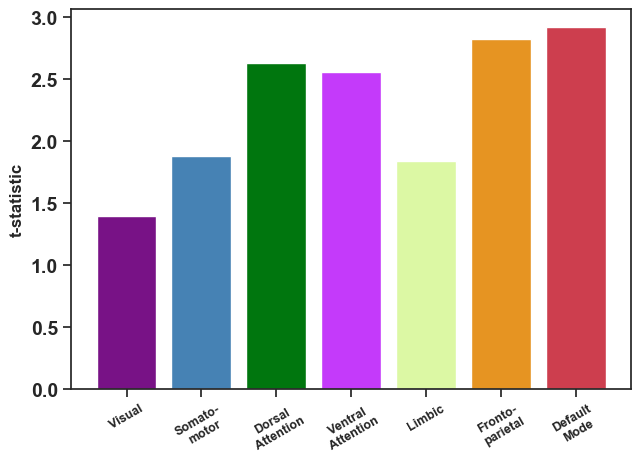

In [22]:
yeo_tstat_mean = slm_model_yeo.t.flatten()
yeo_p_value_mean = slm_model_yeo.Q

plt.bar(
    np.arange(7),
    yeo_tstat_mean,
    color=yeo_colormap,
    #error_kw={"elinewidth": 5},
)
plt.xticks(np.arange(7), yeo_network_names_twolines, rotation=30, fontsize=9)
plt.yticks(fontsize=14)
plt.ylabel("t-statistic", fontdict={"fontsize": 12})
plt.gcf().subplots_adjust(left=0.2, bottom=0.5)
plt.show()

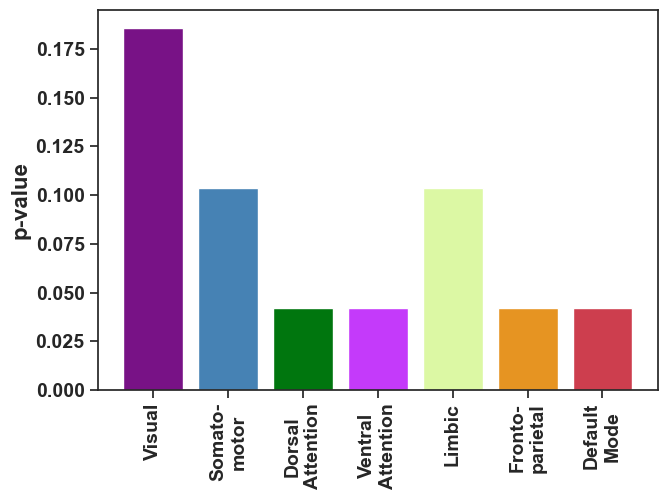

In [23]:
plt.bar(
    np.arange(7),
    yeo_p_value_mean,
    color=yeo_colormap,
    error_kw={"elinewidth": 5},
)
plt.xticks(np.arange(7), yeo_network_names_twolines, rotation=90, fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("p-value", fontdict={"fontsize": 16})
plt.gcf().subplots_adjust(left=0.2, bottom=0.5)
plt.show()

In [24]:
# Flatten the data and prepare the DataFrame in long format
data = []
for i, row in enumerate(all_arrays_yeo):
    participant_id = participants_data.participant_id[i % 14]  # Get participant ID (repeats every 14 rows)
    condition = 'DMT + har' if i < 14 else 'Placebo'  # Assign condition based on row index
    for network_name, value in zip(yeo_network_names_short, row):  # Iterate over Yeo networks and their values
        data.append([participant_id, condition, network_name, value])  # Append long-format data

# Create the long-format DataFrame
df_yeo_values = pd.DataFrame(data, columns=['participant_id', 'condition', 'yeo_network', 'CMRglc'])


### Plot the network differences 

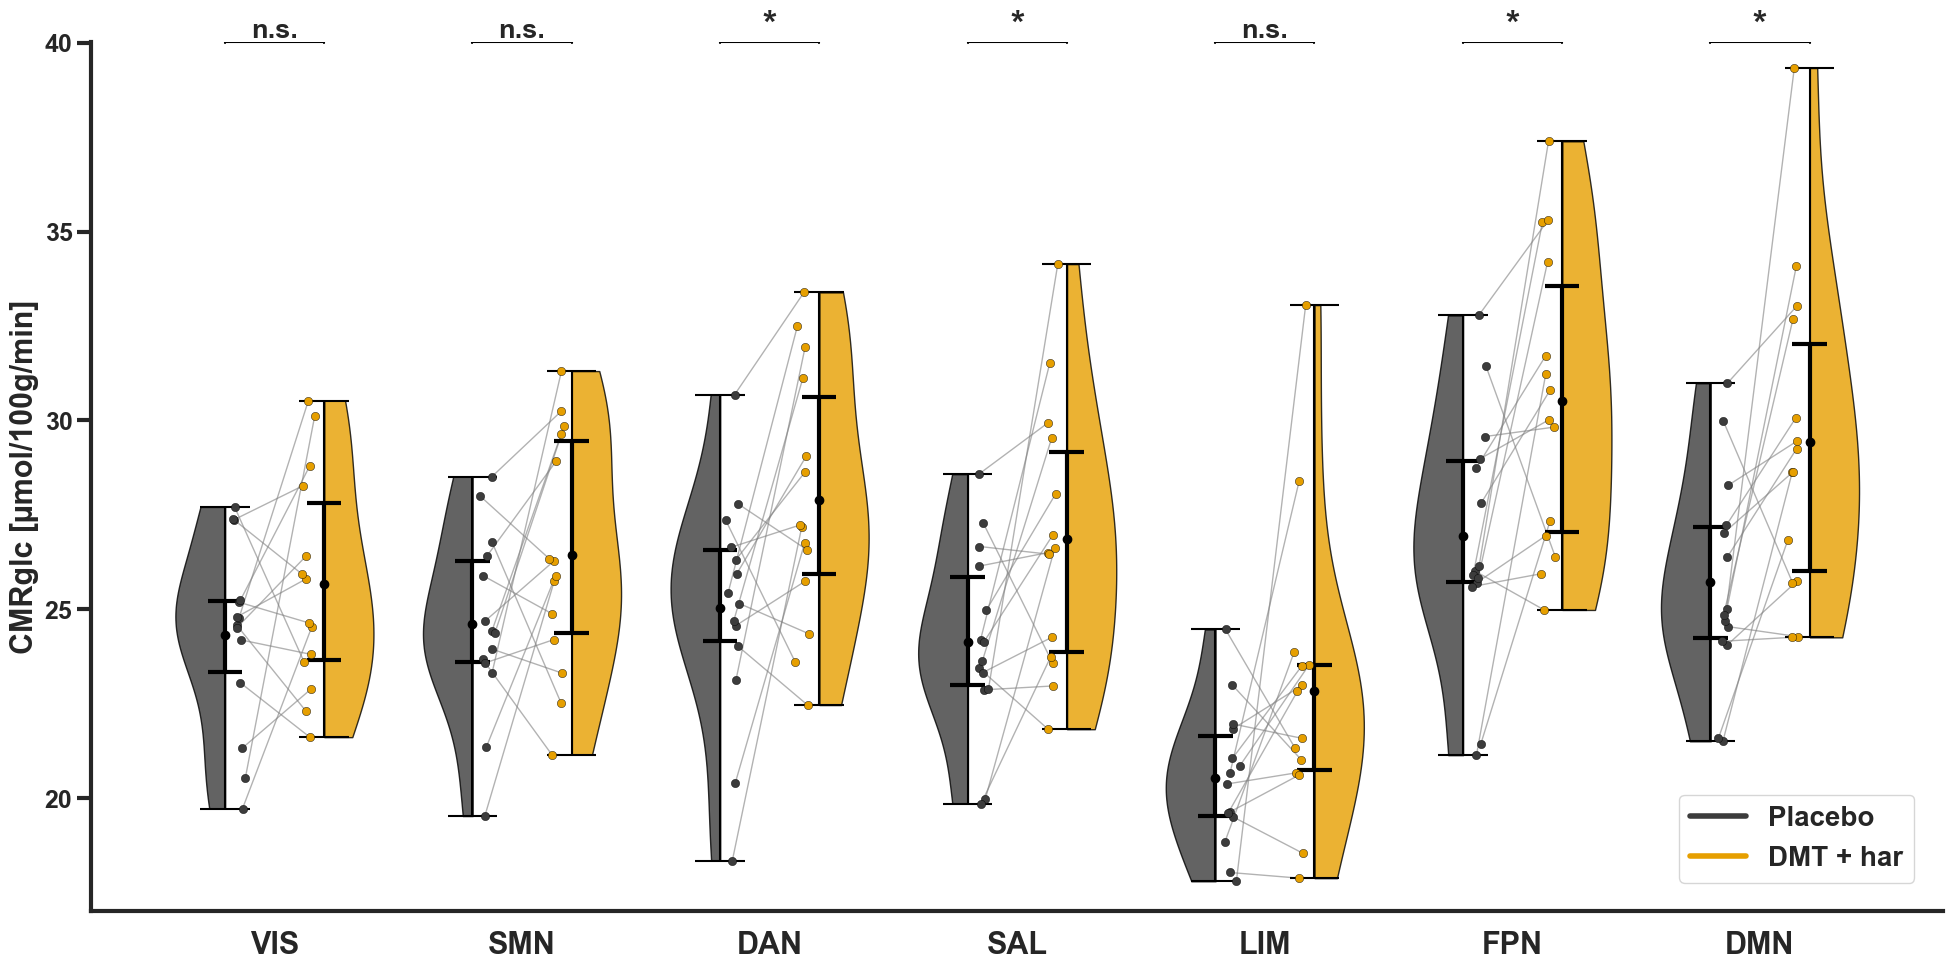

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib

sns.set_theme(style="ticks", rc={"figure.figsize": (20, 10)}, font_scale=1.4)
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})

# Settings
offset = 0.2
jitter_strength = 0.015
colors = {'Placebo': '#3C3C3C', 'DMT + har': '#E69F00'}
conditions = ['Placebo', 'DMT + har']
networks = yeo_network_names_short
subjects = df_yeo_values['participant_id'].unique()

fig, ax = plt.subplots(figsize=(20, 10))

# Iterate over networks
for i, net in enumerate(networks):
    df_net = df_yeo_values[df_yeo_values['yeo_network'] == net]

    # Violin plots (no change here — violins stay at offset)
    for side, condition in zip(['left', 'right'], conditions):
        df_cond = df_net[df_net['condition'] == condition]
        values = df_cond['CMRglc'].values

        parts = ax.violinplot(
            dataset=values,
            positions=[i - offset if condition == 'Placebo' else i + offset],
            showextrema=True,
            widths=0.4
        )

        for pc in parts['bodies']:
            pc.set_facecolor(colors[condition])
            pc.set_edgecolor('black')
            pc.set_alpha(0.8)
            path = pc.get_paths()[0]
            vertices = path.vertices
            mean_x = np.mean(vertices[:, 0])

            if side == 'left':
                vertices[:, 0] = np.clip(vertices[:, 0], -np.inf, mean_x)
                ax.plot(i-offset, np.mean(values), 'o', color='black', markersize=6,)  # Mean marker
                # Add vertical lines for quantiles to resemble a boxplot on the right
                q1, q3 = np.percentile(values, [25, 75])
                ax.vlines(i-offset, q1, q3, color='black', linestyle='-', lw=3)  # Interquartile range
                ax.hlines(q1, i-offset-0.07, i-offset+0.07, color='black', linestyle='-', lw=3)  # Lower quantile line
                ax.hlines(q3, i-offset-0.07, i-offset+0.07, color='black', linestyle='-', lw=3)  # Upper quantile line
            else:
                vertices[:, 0] = np.clip(vertices[:, 0], mean_x, np.inf)
                ax.plot(i+offset, np.mean(values), 'o', color='black', markersize=6,)  # Mean marker
                # Add vertical lines for quantiles to resemble a boxplot on the right
                q1, q3 = np.percentile(values, [25, 75])
                ax.vlines(i+offset, q1, q3, color='black', linestyle='-', lw=3)  # Interquartile range
                ax.hlines(q1, i+offset-0.07, i+offset+0.07, color='black', linestyle='-', lw=3)  # Lower quantile line
                ax.hlines(q3, i+offset-0.07, i+offset+0.07, color='black', linestyle='-', lw=3)  # Upper quantile line


        # Customize the appearance of the violin plot components
        parts['cbars'].set_color('black')  # Central line
        parts['cmins'].set_color('black')  # Bottom of the violin
        parts['cmaxes'].set_color('black')  # Top of the violin

    # Individual points — changed only x values
    for subj in subjects:
        subj_data = df_net[df_net['participant_id'] == subj]
        if len(subj_data) == 2:
            y_placebo = subj_data[subj_data['condition'] == 'Placebo']['CMRglc'].values[0]
            y_dmt = subj_data[subj_data['condition'] == 'DMT + har']['CMRglc'].values[0]

            jitter = np.random.normal(0, jitter_strength)
            x_placebo = i - offset*0.7 + jitter                 
            x_dmt = i + offset*0.7 + jitter                   

            ax.plot([x_placebo, x_dmt], [y_placebo, y_dmt], color='gray', alpha=0.6, lw=1, zorder=1)
            ax.scatter(x_placebo, y_placebo, color=colors['Placebo'], zorder=2, alpha=1, edgecolor='black', linewidth=0.3)
            ax.scatter(x_dmt, y_dmt, color=colors['DMT + har'], zorder=2, alpha=1, edgecolor='black', linewidth=0.3)

# Formatting
sns.despine()
ax.set_xticks(range(len(networks)))
ax.set_xticklabels(networks, fontsize=22, weight='bold')
ax.set_ylabel('CMRglc [µmol/100g/min]', fontsize=22, weight='bold')
ax.set_xlabel(None)
ax.set_ylim(17, 40)
ax.tick_params(axis='y', which='major', labelsize=18)#, width=2, length=5)
ax.spines['left'].set_linewidth(3)
ax.spines['bottom'].set_linewidth(3)
ax.tick_params(axis='y', which='both', width=3, length=10)
ax.tick_params(axis='x', which='both', width=2, color='white', length=10)

# Custom legend for conditions
handles = [matplotlib.lines.Line2D([0], [0], color=color, lw=4) for color in colors.values()]
labels = list(colors.keys())
ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.85, 0.15), fontsize=20)

# Statistical annotations
annotations = []
for i, net in enumerate(networks):
    x1 = i - offset  # DMT side
    x2 = i + offset  # Placebo side
    pval = yeo_p_value_mean[i]

    annotations.append(((x1), (x2), pval))
#starbars.draw_annotation(annotations, fontsize=30, text_distance=0.0, top_margin=0.05, bar_margin=0)
draw_flat_annotations(ax, annotations, top_margin=0.01, text_distance=0.005, fontsize=26)
plt.tight_layout()
plt.savefig(f"{figure_output_path}/CMRglc_yeo_violin_connected_desc-sm6.png", dpi=600, bbox_inches='tight')
# plt.close()

### PCA of paired DMT - placebo Yeo-7 deltas

In [26]:
# Build a paired subject x network matrix of DMT+har minus placebo CMRglc deltas.
paired_subjects = [
    subject for subject in participants_data['participant_id']
    if subject in drug_cmrglc_maps and subject in placebo_cmrglc_maps
]

drug_mean_cmrglc_yeo7_paired = np.array([
    np.squeeze(
        yeo_networks_associations(
            np.concatenate([drug_cmrglc_maps[subject]['left'], drug_cmrglc_maps[subject]['right']]),
            'fsaverage',
        )
    )
    for subject in paired_subjects
])

placebo_mean_cmrglc_yeo7_paired = np.array([
    np.squeeze(
        yeo_networks_associations(
            np.concatenate([placebo_cmrglc_maps[subject]['left'], placebo_cmrglc_maps[subject]['right']]),
            'fsaverage',
        )
    )
    for subject in paired_subjects
])

delta_cmrglc_yeo7 = drug_mean_cmrglc_yeo7_paired - placebo_mean_cmrglc_yeo7_paired
delta_cmrglc_yeo7_df = pd.DataFrame(
    delta_cmrglc_yeo7,
    index=paired_subjects,
    columns=yeo_network_names_short,
)

# Z-score each network across subjects so PCA captures shared covariance structure
# rather than being dominated by networks with larger raw variance.
network_means = delta_cmrglc_yeo7.mean(axis=0, keepdims=True)
network_stds = delta_cmrglc_yeo7.std(axis=0, ddof=1, keepdims=True)
network_stds[network_stds == 0] = 1.0
delta_cmrglc_yeo7_z = (delta_cmrglc_yeo7 - network_means) / network_stds

u, s, vt = np.linalg.svd(delta_cmrglc_yeo7_z, full_matrices=False)
explained_variance = (s ** 2) / (delta_cmrglc_yeo7_z.shape[0] - 1)
explained_variance_ratio = explained_variance / explained_variance.sum()
pc_labels = [f'PC{i + 1}' for i in range(vt.shape[0])]

delta_cmrglc_yeo7_scores_df = pd.DataFrame(
    u * s,
    index=paired_subjects,
    columns=pc_labels,
)

delta_cmrglc_yeo7_loadings_df = pd.DataFrame(
    vt.T,
    index=yeo_network_names_short,
    columns=pc_labels,
)

delta_cmrglc_yeo7_pca_summary_df = pd.DataFrame({
    'explained_variance': explained_variance,
    'explained_variance_ratio': explained_variance_ratio,
    'cumulative_variance_ratio': np.cumsum(explained_variance_ratio),
}, index=pc_labels)

delta_cmrglc_yeo7_pca_summary_df.round(3)


,explained_variance,explained_variance_ratio,cumulative_variance_ratio
PC1,6.566,0.938,0.938
PC2,0.363,0.052,0.990
PC3,0.027,0.004,0.994
PC4,0.018,0.003,0.996
PC5,0.015,0.002,0.999
PC6,0.008,0.001,1.000
PC7,0.001,0.000,1.000


/var/folders/gj/d44qt0ss6bbchgr8g2vwyj4r0000gn/T/ipykernel_22521/794232330.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(axes[0].get_yticklabels(), weight='bold')


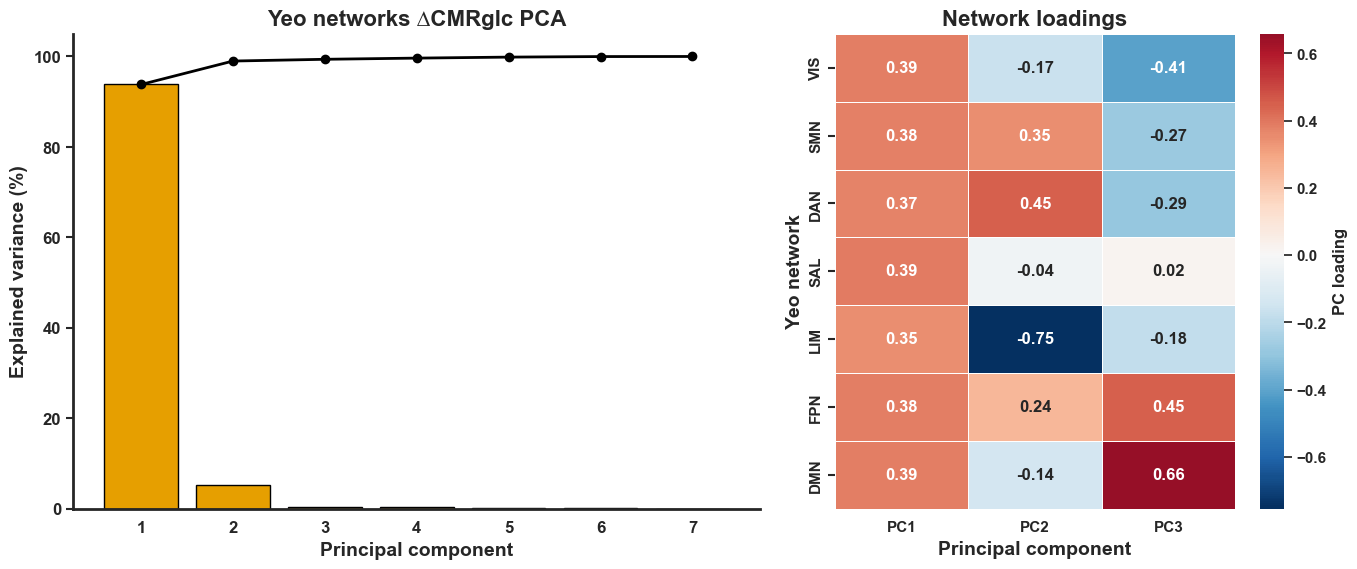

In [27]:
n_plot_components = min(3, len(pc_labels))
loadings_to_plot = delta_cmrglc_yeo7_loadings_df.iloc[:, :n_plot_components]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    gridspec_kw={'width_ratios': [1.1, 0.8]},
)

component_numbers = np.arange(1, len(explained_variance_ratio) + 1)
axes[0].bar(
    component_numbers,
    explained_variance_ratio * 100,
    color='#E69F00',
    edgecolor='black',
)
axes[0].plot(
    component_numbers,
    np.cumsum(explained_variance_ratio) * 100,
    color='black',
    marker='o',
    linewidth=2,
)

axes[0].set_xticks(component_numbers)
axes[0].set_xlabel('Principal component', fontsize=14, weight='bold')
axes[0].set_ylabel('Explained variance (%)', fontsize=14, weight='bold')
axes[0].set_title('Yeo networks ∆CMRglc PCA', fontsize=16, weight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), weight='bold')
axes[0].set_yticklabels(axes[0].get_yticklabels(), weight='bold')
axes[0].set_ylim(0, 105)
sns.despine()
axes[0].tick_params(axis='y', which='both', width=1.5, length=5, labelsize=12)
axes[0].tick_params(axis='x', which='both', width=1.5, color='white', length=5, labelsize=12)
axes[0].spines['left'].set_linewidth(2)
axes[0].spines['bottom'].set_linewidth(2)

heatmap = sns.heatmap(
    loadings_to_plot,
    ax=axes[1],
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'fontsize': 12, 'fontweight': 'bold'},
    linewidths=0.5,
    cbar_kws={'label': 'PC loading'},
)

cbar = heatmap.collections[0].colorbar
cbar.set_label('PC loading', fontsize=12, fontweight='bold')
cbar.ax.tick_params(labelsize=11)

for ticklabel in cbar.ax.get_yticklabels():
    ticklabel.set_fontweight('bold')

axes[1].set_title('Network loadings', fontsize=16, weight='bold')
axes[1].set_xlabel('Principal component', fontsize=14, weight='bold')
axes[1].set_ylabel('Yeo network', fontsize=14, weight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), weight='bold')
axes[1].set_yticklabels(axes[1].get_yticklabels(), weight='bold')
axes[1].tick_params(axis='y', which='both', width=1.5, length=5, labelsize=11)
axes[1].tick_params(axis='x', which='both', width=1.5, color='white', length=5, labelsize=11)
#axes[1].tick_params(axis='y', which='major', labelsize=12)#, width=2, length=5)
axes[1].spines['left'].set_linewidth(2)
axes[1].spines['bottom'].set_linewidth(2)

#axes[0].text(-0.1, 1.1, "C", transform=axes[0].transAxes, fontsize=20, fontweight='bold', va='top', ha='left')
#axes[1].text(-0.15, 1.1, "D", transform=axes[1].transAxes, fontsize=20, fontweight='bold', va='top', ha='left')


plt.tight_layout()
plt.savefig(f'{figure_output_path}/delta_cmrglc_yeo7_pca_summary_desc-sm6.png', dpi=600, bbox_inches='tight')
plt.show()


### Transmodal vs unimodal and left vs right hemisphere tests

In [28]:
from scipy.stats import ttest_rel

# Primary grouping excludes the limbic network because it is not cleanly classified as
# unimodal or transmodal in the reviewer's requested comparison.
unimodal_labels = {1, 2}  # VIS, SMN
transmodal_labels = {3, 4, 6, 7}  # DAN, SAL, FPN, DMN
transmodal_plus_limbic_labels = {3, 4, 5, 6, 7}

n_left_vertices = len(drug_cmrglc_maps[paired_subjects[0]]['left'])
n_right_vertices = len(drug_cmrglc_maps[paired_subjects[0]]['right'])
yeo_left_labels = yeo_network_parcellation[:n_left_vertices]
yeo_right_labels = yeo_network_parcellation[n_left_vertices:n_left_vertices + n_right_vertices]

surface_group_delta_rows = []
for subject in paired_subjects:
    left_delta = drug_cmrglc_maps[subject]['left'] - placebo_cmrglc_maps[subject]['left']
    right_delta = drug_cmrglc_maps[subject]['right'] - placebo_cmrglc_maps[subject]['right']

    left_unimodal = np.nanmean(left_delta[np.isin(yeo_left_labels, list(unimodal_labels))])
    right_unimodal = np.nanmean(right_delta[np.isin(yeo_right_labels, list(unimodal_labels))])
    left_transmodal = np.nanmean(left_delta[np.isin(yeo_left_labels, list(transmodal_labels))])
    right_transmodal = np.nanmean(right_delta[np.isin(yeo_right_labels, list(transmodal_labels))])
    left_transmodal_plus_limbic = np.nanmean(left_delta[np.isin(yeo_left_labels, list(transmodal_plus_limbic_labels))])
    right_transmodal_plus_limbic = np.nanmean(right_delta[np.isin(yeo_right_labels, list(transmodal_plus_limbic_labels))])

    surface_group_delta_rows.append({
        'participant_id': subject,
        'left_unimodal': left_unimodal,
        'right_unimodal': right_unimodal,
        'left_transmodal': left_transmodal,
        'right_transmodal': right_transmodal,
        'left_transmodal_plus_limbic': left_transmodal_plus_limbic,
        'right_transmodal_plus_limbic': right_transmodal_plus_limbic,
        'left_mean_delta': np.nanmean(left_delta),
        'right_mean_delta': np.nanmean(right_delta),
    })

surface_group_delta_df = pd.DataFrame(surface_group_delta_rows).set_index('participant_id')
surface_group_delta_df['unimodal_mean'] = surface_group_delta_df[['left_unimodal', 'right_unimodal']].mean(axis=1)
surface_group_delta_df['transmodal_mean'] = surface_group_delta_df[['left_transmodal', 'right_transmodal']].mean(axis=1)
surface_group_delta_df['transmodal_plus_limbic_mean'] = surface_group_delta_df[['left_transmodal_plus_limbic', 'right_transmodal_plus_limbic']].mean(axis=1)
surface_group_delta_df['left_group_difference'] = surface_group_delta_df['left_transmodal'] - surface_group_delta_df['left_unimodal']
surface_group_delta_df['right_group_difference'] = surface_group_delta_df['right_transmodal'] - surface_group_delta_df['right_unimodal']

surface_group_stats = {
    'transmodal_vs_unimodal': ttest_rel(surface_group_delta_df['transmodal_mean'], surface_group_delta_df['unimodal_mean']),
    'hemisphere_left_vs_right_whole_cortex': ttest_rel(surface_group_delta_df['left_mean_delta'], surface_group_delta_df['right_mean_delta']),
    'transmodal_plus_limbic_vs_unimodal_sensitivity': ttest_rel(surface_group_delta_df['transmodal_plus_limbic_mean'], surface_group_delta_df['unimodal_mean']),
}

surface_group_stats_df = pd.DataFrame({
    't_value': [surface_group_stats[key].statistic for key in surface_group_stats],
    'p_value': [surface_group_stats[key].pvalue for key in surface_group_stats],
    'mean_1': [
        surface_group_delta_df['transmodal_mean'].mean(),
        surface_group_delta_df['left_mean_delta'].mean(),
        surface_group_delta_df['transmodal_plus_limbic_mean'].mean(),
    ],
    'mean_2': [
        surface_group_delta_df['unimodal_mean'].mean(),
        surface_group_delta_df['right_mean_delta'].mean(),
        surface_group_delta_df['unimodal_mean'].mean(),
    ],
}, index=list(surface_group_stats.keys()))

surface_group_stats_df.round(4)


,t_value,p_value,mean_1,mean_2
transmodal_vs_unimodal,6.7332,0.0000,3.2964,1.6311
hemisphere_left_vs_right_whole_cortex,-1.0641,0.3067,2.3194,2.5162
transmodal_plus_limbic_vs_unimodal_sensitivity,6.0886,0.0000,3.1790,1.6311


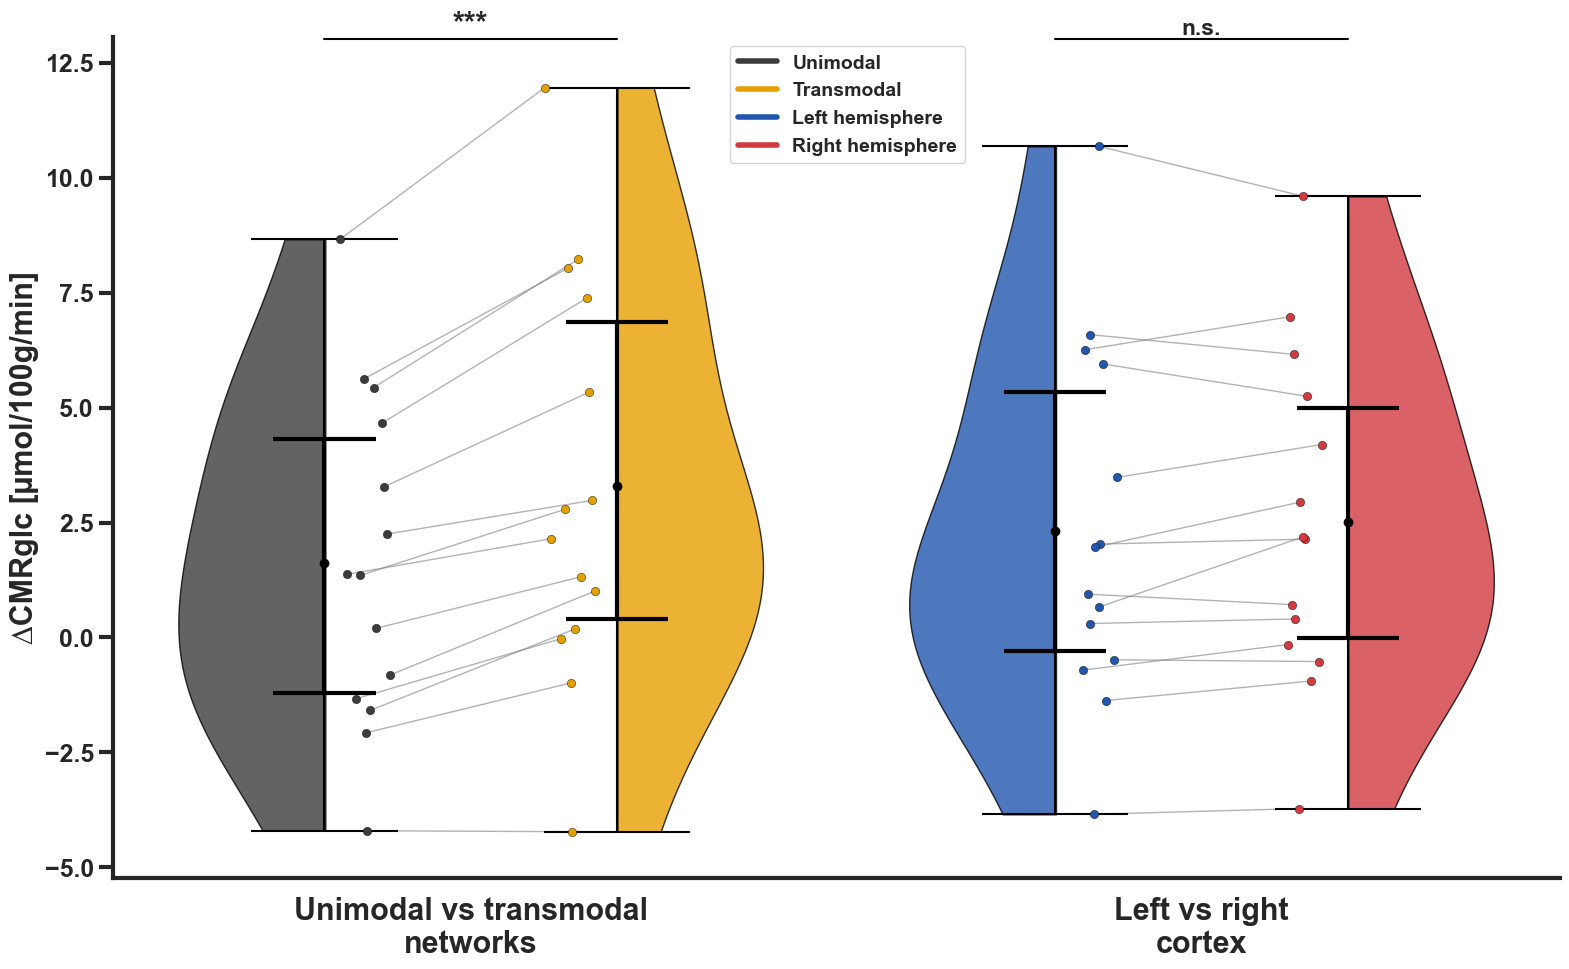

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib

sns.set_theme(style="ticks", rc={"figure.figsize": (16, 10)}, font_scale=1.4)
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})

offset = 0.2
jitter_strength = 0.015
comparison_colors = {
    'Unimodal': '#3C3C3C',
    'Transmodal': '#E69F00',
    'Left hemisphere': "#2056AD",
    'Right hemisphere': "#D13A3F",
}

comparison_specs = [
    {
        'group_label': 'Unimodal vs transmodal\nnetworks',
        'left_label': 'Unimodal',
        'right_label': 'Transmodal',
        'left_values': surface_group_delta_df['unimodal_mean'],
        'right_values': surface_group_delta_df['transmodal_mean'],
        'p_value': surface_group_stats['transmodal_vs_unimodal'].pvalue,
    },
    {
        'group_label': 'Left vs right\ncortex',
        'left_label': 'Left hemisphere',
        'right_label': 'Right hemisphere',
        'left_values': surface_group_delta_df['left_mean_delta'],
        'right_values': surface_group_delta_df['right_mean_delta'],
        'p_value': surface_group_stats['hemisphere_left_vs_right_whole_cortex'].pvalue,
    },
]

fig, ax = plt.subplots(figsize=(16, 10))

for i, spec in enumerate(comparison_specs):
    for side, label, values in zip(
        ['left', 'right'],
        [spec['left_label'], spec['right_label']],
        [spec['left_values'].values, spec['right_values'].values],
    ):
        position = i - offset if side == 'left' else i + offset
        parts = ax.violinplot(
            dataset=values,
            positions=[position],
            showextrema=True,
            widths=0.4
        )

        for pc in parts['bodies']:
            pc.set_facecolor(comparison_colors[label])
            pc.set_edgecolor('black')
            pc.set_alpha(0.8)
            path = pc.get_paths()[0]
            vertices = path.vertices
            mean_x = np.mean(vertices[:, 0])

            if side == 'left':
                vertices[:, 0] = np.clip(vertices[:, 0], -np.inf, mean_x)
                ax.plot(position, np.mean(values), 'o', color='black', markersize=6)
                q1, q3 = np.percentile(values, [25, 75])
                ax.vlines(position, q1, q3, color='black', linestyle='-', lw=3)
                ax.hlines(q1, position - 0.07, position + 0.07, color='black', linestyle='-', lw=3)
                ax.hlines(q3, position - 0.07, position + 0.07, color='black', linestyle='-', lw=3)
            else:
                vertices[:, 0] = np.clip(vertices[:, 0], mean_x, np.inf)
                ax.plot(position, np.mean(values), 'o', color='black', markersize=6)
                q1, q3 = np.percentile(values, [25, 75])
                ax.vlines(position, q1, q3, color='black', linestyle='-', lw=3)
                ax.hlines(q1, position - 0.07, position + 0.07, color='black', linestyle='-', lw=3)
                ax.hlines(q3, position - 0.07, position + 0.07, color='black', linestyle='-', lw=3)

        parts['cbars'].set_color('black')
        parts['cmins'].set_color('black')
        parts['cmaxes'].set_color('black')

    for subject in surface_group_delta_df.index:
        y_left = spec['left_values'].loc[subject]
        y_right = spec['right_values'].loc[subject]
        jitter = np.random.normal(0, jitter_strength)
        x_left = i - offset*0.7 + jitter
        x_right = i + offset*0.7 + jitter

        ax.plot([x_left, x_right], [y_left, y_right], color='gray', alpha=0.6, lw=1, zorder=1)
        ax.scatter(x_left, y_left, color=comparison_colors[spec['left_label']], zorder=2, alpha=1, edgecolor='black', linewidth=0.3)
        ax.scatter(x_right, y_right, color=comparison_colors[spec['right_label']], zorder=2, alpha=1, edgecolor='black', linewidth=0.3)

sns.despine()
ax.set_xticks(range(len(comparison_specs)))
ax.set_xticklabels([spec['group_label'] for spec in comparison_specs], fontsize=22, weight='bold')
ax.set_ylabel('∆CMRglc [µmol/100g/min]', fontsize=22, weight='bold')
ax.set_xlabel(None)

all_plot_values = np.concatenate([
    comparison_specs[0]['left_values'].values,
    comparison_specs[0]['right_values'].values,
    comparison_specs[1]['left_values'].values,
    comparison_specs[1]['right_values'].values,
])
ax.set_ylim(all_plot_values.min() - 1.0, all_plot_values.max() + 1.0)
ax.tick_params(axis='y', which='major', labelsize=18)
ax.spines['left'].set_linewidth(3)
ax.spines['bottom'].set_linewidth(3)
ax.tick_params(axis='y', which='both', width=3, length=10)
ax.tick_params(axis='x', which='both', width=2, color='white', length=10)

handles = [matplotlib.lines.Line2D([0], [0], color=color, lw=4) for color in comparison_colors.values()]
labels = list(comparison_colors.keys())
ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.42, 1.0), fontsize=14)

annotations = []
for i, spec in enumerate(comparison_specs):
    x1 = i - offset
    x2 = i + offset
    annotations.append((x1, x2, spec['p_value']))

draw_flat_annotations(ax, annotations, top_margin=0.05, text_distance=0.03, fontsize=22)
plt.tight_layout()
plt.savefig(f'{figure_output_path}/delta_cmrglc_surface_grouping_and_hemisphere_desc-sm6.png', dpi=600, bbox_inches='tight')
plt.show()

